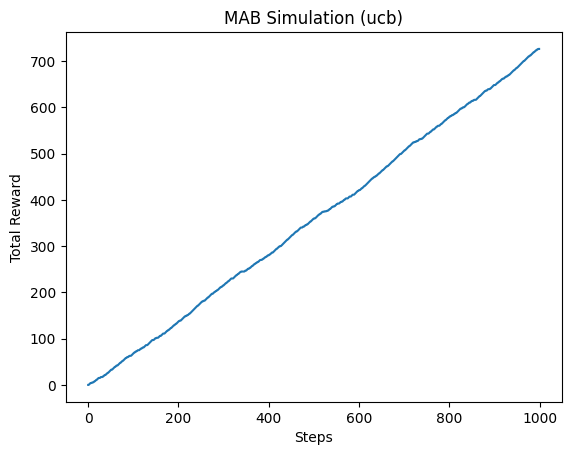

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ネットワーク環境のシミュレータ（後で本物のパラメータに差し替える）
class NetworkEnvironment:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        # 仮の成功確率（後で無線・有線のパラメータに基づく計算式にする）
        self.true_rewards = np.linspace(0.1, 0.8, n_arms) 

    def get_reward(self, arm_index):
        # 現状は仮のスロットマシン的な報酬（0か1）を返す
        # 将来的にはここに CSMA/CA の遅延やスループットを反映させる
        if np.random.rand() < self.true_rewards[arm_index]:
            return 1.0
        else:
            return 0.0

# 2. MABエージェント（アルゴリズム本体）
class MABAgent:
    def __init__(self, n_arms, mode='epsilon', epsilon=0.1):
        self.n_arms = n_arms
        self.mode = mode
        self.epsilon = epsilon
        self.counts = np.zeros(n_arms)  # 各アームを引いた回数
        self.values = np.zeros(n_arms)  # 各アームの推定報酬値
        self.total_reward = 0
        self.reward_history = []

    def select_arm(self):
        if self.mode == 'epsilon':
            # Epsilon-Greedy: 一定確率で探索、残りは現状のベストを選択
            if np.random.rand() < self.epsilon:
                return np.random.randint(self.n_arms)
            return np.argmax(self.values)
        
        elif self.mode == 'ucb':
            # UCB: 試行回数が少ないアームを優先的に選ぶ（ボーナスを与える）
            total_counts = np.sum(self.counts)
            if total_counts < self.n_arms:
                return int(total_counts) # 最初は全アーム1回ずつ試す
            
            # UCBスコア = 推定平均 + sqrt(2 * log(全試行回数) / そのアームの試行回数)
            ucb_values = self.values + np.sqrt(2 * np.log(total_counts) / (self.counts + 1e-5))
            return np.argmax(ucb_values)

    def update(self, arm_index, reward):
        self.counts[arm_index] += 1
        n = self.counts[arm_index]
        # 逐次更新式で平均報酬を更新
        self.values[arm_index] = ((n - 1) * self.values[arm_index] + reward) / n
        self.total_reward += reward
        self.reward_history.append(self.total_reward)

# 3. 実行セクション
n_arms = 5
steps = 1000
env = NetworkEnvironment(n_arms)
agent = MABAgent(n_arms, mode='ucb') # 'epsilon' か 'ucb' を選べる

for _ in range(steps):
    arm = agent.select_arm()
    reward = env.get_reward(arm)
    agent.update(arm, reward)

# 結果の可視化
plt.plot(agent.reward_history)
plt.xlabel("Steps")
plt.ylabel("Total Reward")
plt.title(f"MAB Simulation ({agent.mode})")
plt.show()

・今の悩み: 無線と有線のパラメータ、何が使えるか？

・調べたい論文: 「MAB Network Optimization」「CSMA/CA Bandit」などのキーワードで検索。

アームの仮案:
1.経路A（無線優先）
2.経路B（有線優先）
3.経路C（負荷分散）

・アームの中身を仮決めする
例：arm 0 = 無線（CSMA/CA）メイン、arm 1 = 有線メイン、arm 2 = 両方を50:50で使う。

・報酬の計算式（Reward Function）を作る
今の return 1.0 or 0.0 の部分を、return (有線のスループット) + (無線のスループット) - (遅延によるペナルティ) のような計算式に変える。

・CSMA/CAの影響を入れる
「端末が多い環境」という設定なので、アームを選んだ時に一定の確率で「衝突（Collision）」が発生して、報酬がガクンと下がる仕組みを入れてみる。